# Detección de Inyecciones SQL mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático

## Introducción
Por Gonzalo Benito, Lic. en Sistemas de Información, Universidad Nacional de Luján, Argentina.

Este trabajo propone desarrollar un sistema de detección de ataques de Inyección SQL utilizando técnicas de procesamiento de lenguaje natural (NLP) y algoritmos de machine learning. Se empleó un dataset obtenido de Kaggle que contiene sentencias SQL etiquetadas como peligrosas o benignas. La metodología incluyó la transformación de las sentencias en vectores mediante una matriz TF-IDF sobre n-gramas de caracteres (trigramas solamente) ~~y palabras~~, seguida de la aplicación de algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo fue evaluar y comparar el desempeño de los modelos mediante métricas de precisión, recall y F1-score, y **demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning**.

#### Detalles de lo que se incluirá en este trabajo
La metodología seguirá un enfoque basado en una matriz TF-IDF (matriz dispersa o *sparse*) sobre n-gramas de caracteres (y de palabras también). Con este método, cada sentencia se transforma en un vector o fila de la matriz; las columnas corresponden a n-gramas de longitud fija (por ejemplo, de 3 a 5 caracteres) o a combinaciones de palabras (más especificamente combinaciones de *tokens*, que llamaremos unigramas, bigramas o trigramas); y los valores de cada celda reflejan la frecuencia (o el peso TF-IDF, según la configuración utilizada) de cada n-grama en la sentencia. Se probarán diferentes configuraciones para los algoritmos usados durante la ingeniería de características (Feature Engineering), y se evaluarán las distintas matrices dispersas obtenidas con algoritmos de clasificación, como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo es evaluar y comparar el desempeño de las distintas configuraciones de los modelos, mediante las métricas de precisión más usadas, y demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning.

## Descripción del dataset
El dataset utilizado es 'SQL Injection Dataset' de Syed Saqlain Hussain (Kaggle), con 30.920 filas y dos columnas principales: `Sentence` (consulta SQL o texto) y `Label` (0=benigna, 1=inyección).

| Atributo | Tipo | Descripción |
| -------- | ---- | ----------- |
| Sentence | texto | Consulta SQL completa o texto |
| Label | categórica | 0 = no inyección, 1 = inyección SQL |

De la variable Sentence se obtendrá el conjunto de features durante la fase de Feature Engineering, con clases como CountVectorizer, TfidfVectorizer, o Word2vec.

Link del dataset: https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset

## Instalación de librerías necesarias

In [1]:
# Dependencias
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install numpy==1.26.4
%pip install imbalanced-learn

import pandas as pd
import gc  # Para gestión de memoria

# Configuración para optimizar memoria
pd.options.mode.copy_on_write = True  # Evita copias innecesarias en pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importación del dataset y selección de features

In [2]:
data: pd.DataFrame = pd.read_csv(
    "./data/SQLiV3.csv"
)  # El dataset debe tener columnas 'Sentence' y 'Label'
data

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [3]:
data = data[["Sentence", "Label"]].copy()  # Seleccionar solo las columnas necesarias
data["Sentence"] = data["Sentence"].astype(str)
data["length"] = data["Sentence"].apply(len)
data

,Sentence,Label,length
0,""" or pg_sleep ( __TIME__ ) --",1,33
1,create user name identified by pass123 tempora...,NaN,89
2,AND 1 = utl_inaddr.get_host_address ( ...,1,218
3,select * from users where id = '1' or @ @1 ...,1,90
4,"select * from users where id = 1 or 1#"" ( ...",1,85
...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,37
30915,DELETE FROM tomorrow,0,20
30916,SELECT wide ( s ) FROM west,0,28
30917,SELECT * FROM ( SELECT slide FROM breath ),0,44


## Preprocesamiento

### Limpieza de missing values y ruido

In [4]:
# Eliminar filas donde 'Sentence' es NaN
data = data.dropna(subset=["Sentence"])

# Me quedo solo con las clases 0 y 1 (por si hay algún otro valor en 'Label', como un string)
data = data[data["Label"].isin(["0", "1"])]

## Análisis exploratorio de datos (EDA)
Exploramos la distribución de clases y longitud de sentencias.

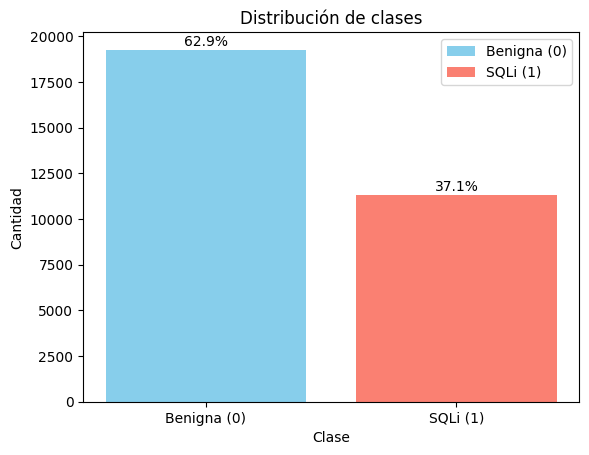

In [5]:
# Distribución de clases
import matplotlib.pyplot as plt

value_counts = data["Label"].value_counts()
percentage = (value_counts / value_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

fig, axes = plt.subplots()
bars = axes.bar(labels, value_counts, color=["skyblue", "salmon"], label=labels)

# Texto de porcentaje arriba de cada barra
for bar, pct in zip(bars, percentage):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

axes.set_title("Distribución de clases")
axes.set_xlabel("Clase")
axes.set_ylabel("Cantidad")
axes.legend()
plt.show()

Las clases están desbalanceadas. La clase mayoritaria es la 0 (sentencias benignas). Recurriremos a técnicas de balanceo para solucionar este problema.

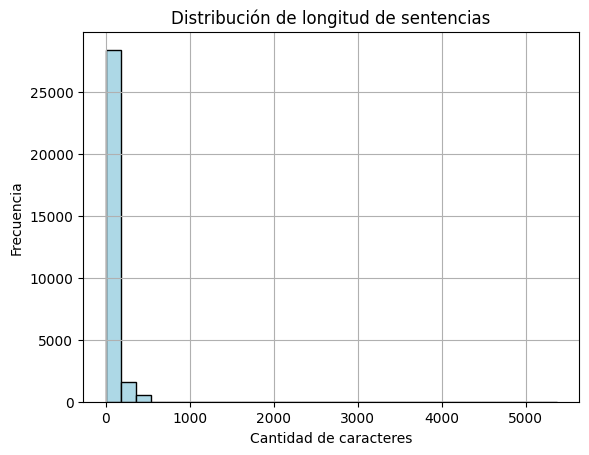

Cantidad de caracteres de la sentencia más larga: 5370


,Sentence,Label,length
19341,de]]> </email_address> <find_account_answer...,0,5370
19667,SELECT wp_posts.* FROM wp_posts LEFT JOIN wp_p...,0,559
19663,SELECT wp_posts.ID FROM wp_posts LEFT JOIN wp_...,0,529
9780,1'|| ( select 'rjis' from dual where 7696 =...,1,456
7270,"-6475"" ) ) ) or 4144 = ( selec...",1,455
...,...,...,...
628,!,1,1
19312,0,1,1
438,?,1,1
106,s,1,1


In [6]:
data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

print(f"Cantidad de caracteres de la sentencia más larga: {data['length'].max()}")
data_sort_by_length = data.sort_values(by="length", ascending=False)
data_sort_by_length

Vemos que la sentencia 19341 tiene una longitud atípica, 10 veces mayor que la segunda sentencia más larga. Esta es benigna. La eliminaremos del dataset por ser un outlier. Luego volvemos a mostrar el histograma de longitudes de sentencia.

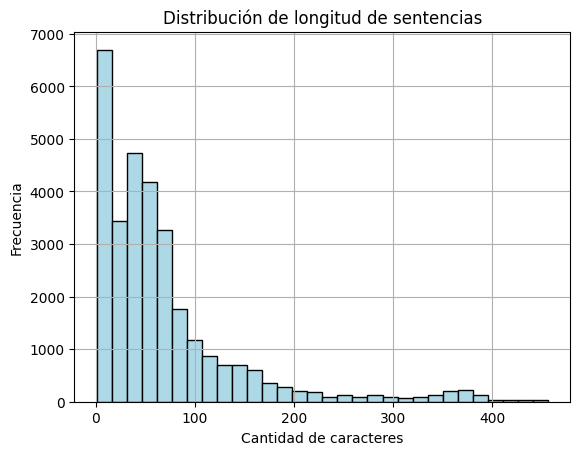

In [7]:
data = data[data["length"] <= 500]
data["length"].max()

data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

## Feature Engineering
Se exploran dos enfoques: TF-IDF y Word2Vec (este último en otro notebook). No se tendrán en cuenta los espacios en blanco de las sentencias.

In [8]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# CONFIGURACIÓN OPTIMIZADA PARA MEMORIA
MAX_FEATURES = 15000  # Limitar número de características para reducir RAM

print("APLICANDO TfIdfVectorizer:")
print(f"- Limitando a máximo {MAX_FEATURES:,} características")
print("- Manteniendo matriz sparse (no conversión a denso)")

tfidf = TfidfVectorizer(
    ngram_range=(3, 3),
    analyzer="char_wb",
    min_df=3,
    max_features=MAX_FEATURES,  # ✓ LIMITAR CARACTERÍSTICAS PARA AHORRAR RAM
    lowercase=True,
    strip_accents="ascii",
    use_idf=False,
    stop_words="english",
    token_pattern=r"\b\w+\b",
)
"""
usar use_idf=False para no penalizar por IDF
usar max_features=integer para limitar el número de características
analyzer='char_wb' hace que excluya los n-gramas con espacios al final o al principio

(*) Al usar analyzer='char_wb', tanto el parámetro token_pattern como stop_words no tienen efecto (se aplican solo cuando analyzer='word)
"""

matriz_rala_tfidf = tfidf.fit_transform(data["Sentence"])

print("✓ Matriz TF-IDF generada:")
print(f"  Forma: {matriz_rala_tfidf.shape}")
print(f"  Tipo: {type(matriz_rala_tfidf)} (SPARSE)")
print(
    f"  Densidad: {matriz_rala_tfidf.nnz / (matriz_rala_tfidf.shape[0] * matriz_rala_tfidf.shape[1]):.4f}"
)

# Mostrar algunos nombres de características (sin convertir a DataFrame denso)
feature_names = tfidf.get_feature_names_out()
print(f"\nPrimeros 10 features: {feature_names[:10].tolist()}")
print(f"Últimos 10 features: {feature_names[-10:].tolist()}")

# IMPORTANTE: NO convertir a DataFrame para ahorrar RAM
# matriz_rala_tfidf_df = pd.DataFrame(matriz_rala_tfidf.toarray(), columns=tfidf.get_feature_names_out())  # ❌ CONSUME MUCHA RAM
print("\n✓ OPTIMIZACIÓN: Matriz mantenida como sparse matrix para ahorrar RAM")

# Guardar en un archivo CSV las características TF-IDF
# X_tfidf_df.to_csv('TF-IDF-2.csv', index=False)

APLICANDO TfIdfVectorizer:
- Limitando a máximo 15,000 características
- Manteniendo matriz sparse (no conversión a denso)


/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(
/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:547: UserWarning: The parameter 'token_pattern' will not be used since 'analyzer' != 'word'
  warnings.warn(


✓ Matriz TF-IDF generada:
  Forma: (30606, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'> (SPARSE)
  Densidad: 0.0031

Primeros 10 features: [' !<', ' " ', ' ""', ' "$', ' "%', ' "&', ' ",', ' "-', ' ".', ' "0']
Últimos 10 features: ['zzk', '{" ', "|' ", "|'q", '|1 ', '|ch', '|| ', "||'", '||1', '||c']

✓ OPTIMIZACIÓN: Matriz mantenida como sparse matrix para ahorrar RAM


### Balanceo de Clases

Como observamos anteriormente, el dataset presenta un desbalance significativo entre las clases. Para mejorar el rendimiento de los modelos y evitar sesgos hacia la clase mayoritaria, aplicaremos la técnica SMOTE (Synthetic Minority Oversampling Technique), que genera muestras sintéticas de la clase minoritaria creando ejemplos interpolados entre muestras existentes. Se optó por SMOTE por sobre RandomOverSampler, para evitar duplicar ejemplos existentes y fomentar la creación de nuevas instancias que reflejen mejor la distribución de la clase minoritaria.

In [9]:
# Preparar datos originales para las siguientes etapas de preprocesamiento
# SMOTE se aplicará más adelante después de la división de datos

# OPTIMIZACIÓN DE MEMORIA: Preparar datos manteniendo formato sparse
print("PREPARANDO DATOS ORIGINALES (OPTIMIZADO PARA MEMORIA):")
print("=" * 55)

# ✓ MANTENER matriz sparse (NO convertir a DataFrame)
X_original = matriz_rala_tfidf  # Usar directamente la matriz sparse
y_original = data["Label"].copy()

# Convertir etiquetas a tipo int8 para ahorrar memoria
y_original = y_original.astype("int8")

print("✓ X_original:")
print(f"  Forma: {X_original.shape}")
print(f"  Tipo: {type(X_original)} (SPARSE - ahorra RAM)")
print(f"  Memoria estimada: ~{X_original.data.nbytes / 1024**2:.1f} MB")

print("\n✓ y_original:")
print(f"  Forma: {len(y_original)}")
print(f"  Tipo: {y_original.dtype} (int8 - ahorra RAM)")
print(f"  Memoria estimada: ~{y_original.nbytes / 1024**2:.1f} MB")

# Liberar variables innecesarias
del data["length"]  # No necesitamos más esta columna
gc.collect()

PREPARANDO DATOS ORIGINALES (OPTIMIZADO PARA MEMORIA):
✓ X_original:
  Forma: (30606, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'> (SPARSE - ahorra RAM)
  Memoria estimada: ~8.3 MB

✓ y_original:
  Forma: 30606
  Tipo: int8 (int8 - ahorra RAM)
  Memoria estimada: ~0.0 MB


0

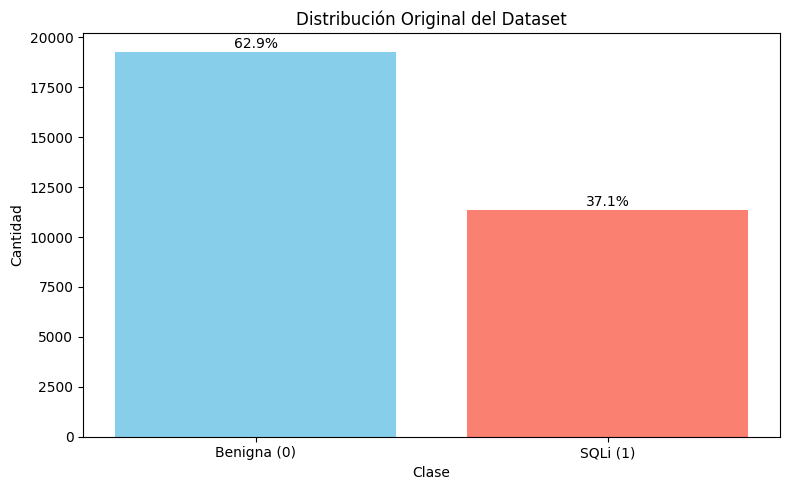

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Visualización de la distribución original
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

# Distribución original
original_counts = data["Label"].value_counts()
original_percentage = (original_counts / original_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

bars1 = ax1.bar(labels, original_counts, color=["skyblue", "salmon"])
for bar, pct in zip(bars1, original_percentage):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

ax1.set_title("Distribución Original del Dataset")
ax1.set_xlabel("Clase")
ax1.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

**Nota: El balanceo se aplicará más adelante solo al conjunto de entrenamiento.**

### ¿Cómo genera SMOTE una instancia sintética en este contexto?

SMOTE no genera nuevas sentencias de texto, sino que crea nuevos vectores en el espacio de características (por ejemplo, TF-IDF o simplemente TF (Term Frequency)). Cada vector representa la frecuencia o importancia de los tokens en una sentencia. Una instancia sintética es simplemente un vector intermedio entre dos ejemplos reales de la clase minoritaria.

A continuación, se muestra un ejemplo simplificado de generación de una instancia sintética con SMOTE:

In [11]:

# Supongamos que estos son dos vectores TF-IDF de la clase minoritaria
vector_a = np.array([1, 0, 2, 0])  # Instancia A
vector_b = np.array([0, 1, 1, 2])  # Instancia B  -> vecino cercano

# SMOTE genera una instancia sintética interpolando (con un parametro alfa) entre ambos
alpha = 0.6  # valor aleatorio entre 0 y 1 generado uniformemente
ejemplo_sintetico = vector_a + alpha * (vector_b - vector_a)

pd.DataFrame(
    {"Vector A": vector_a, "Vector B": vector_b, "Sintético": ejemplo_sintetico}
)

,Vector A,Vector B,Sintético
0,1,0,0.4
1,0,1,0.6
2,2,1,1.4
3,0,2,1.2


### Análisis de Componentes Principales (PCA) 

Para reducir la dimensionalidad de los datos y visualizar mejor las características, aplicamos PCA. Esto nos permite proyectar los datos en un espacio de menor dimensión, facilitando la identificación de patrones y relaciones entre las clases.

Sin embargo, los recursos computacionales son muy limitados, por lo que estamos limitados a trabajar con una cantidad de componentes reducida (en este caso, 100 componentes principales), lo que puede afectar la capacidad del modelo para capturar la complejidad de los datos.

**Importante**: Como se verá en los resultados, los primeros 100 componentes explican solo el **9% de la varianza total** de los datos. Esto sugiere que PCA no está siendo efectivo para reducir la dimensionalidad mientras conserva la información relevante de los datos, derivando en una gran pérdida de información.

Se optó por continuar con este enfoque a pesar de este bajo valor en la varianza capturada, para comprobar si seguían siendo útiles los datos para generalizar. Se exploraron alternativas como TruncatedSVD para futuros trabajos.

### El texto anterior quedó deprecado (se optó por no usar PCA, o sino quedó pendiente probar SVD)

In [12]:
# CONFIGURACIÓN: PCA opcional
APPLY_PCA = True
PCA_COMPONENTS = 2000

print("PROCESAMIENTO DE CARACTERÍSTICAS:")
print("=" * 60)

if APPLY_PCA:
    from sklearn.decomposition import TruncatedSVD  # Mejor para matrices sparse

    print("Aplicando PCA con TruncatedSVD (optimizado para matrices sparse)...")

    # TruncatedSVD es más eficiente que PCA para matrices sparse
    svd = TruncatedSVD(n_components=PCA_COMPONENTS, random_state=0)
    X_processed = svd.fit_transform(X_original)  # X_original ya es sparse

    print(
        f"✓ TruncatedSVD aplicado: {X_original.shape[1]} → {X_processed.shape[1]} características"
    )
    print(f"✓ Varianza explicada: {svd.explained_variance_ratio_.sum():.3f}")
    print(f"✓ Tipo resultante: {type(X_processed)} (denso pero más pequeño)")

    # Liberar memoria de la matriz original
    del X_original
    gc.collect()

    preprocessing_objects = {"svd": svd, "pca_applied": True, "method": "TruncatedSVD"}
else:
    print("PCA desactivado - usando matriz TF-IDF sparse original")
    X_processed = X_original  # Mantener referencia a la matriz sparse

    preprocessing_objects = {"pca_applied": False, "method": "TF-IDF sparse"}

print(f"\n✓ Forma final de X_processed: {X_processed.shape}")

PROCESAMIENTO DE CARACTERÍSTICAS:
Aplicando PCA con TruncatedSVD (optimizado para matrices sparse)...
✓ TruncatedSVD aplicado: 11601 → 2000 características
✓ Varianza explicada: 0.878
✓ Tipo resultante: <class 'numpy.ndarray'> (denso pero más pequeño)

✓ Forma final de X_processed: (30606, 2000)
✓ TruncatedSVD aplicado: 11601 → 2000 características
✓ Varianza explicada: 0.878
✓ Tipo resultante: <class 'numpy.ndarray'> (denso pero más pequeño)

✓ Forma final de X_processed: (30606, 2000)


VISUALIZACIÓN DE COMPONENTES PRINCIPALES:


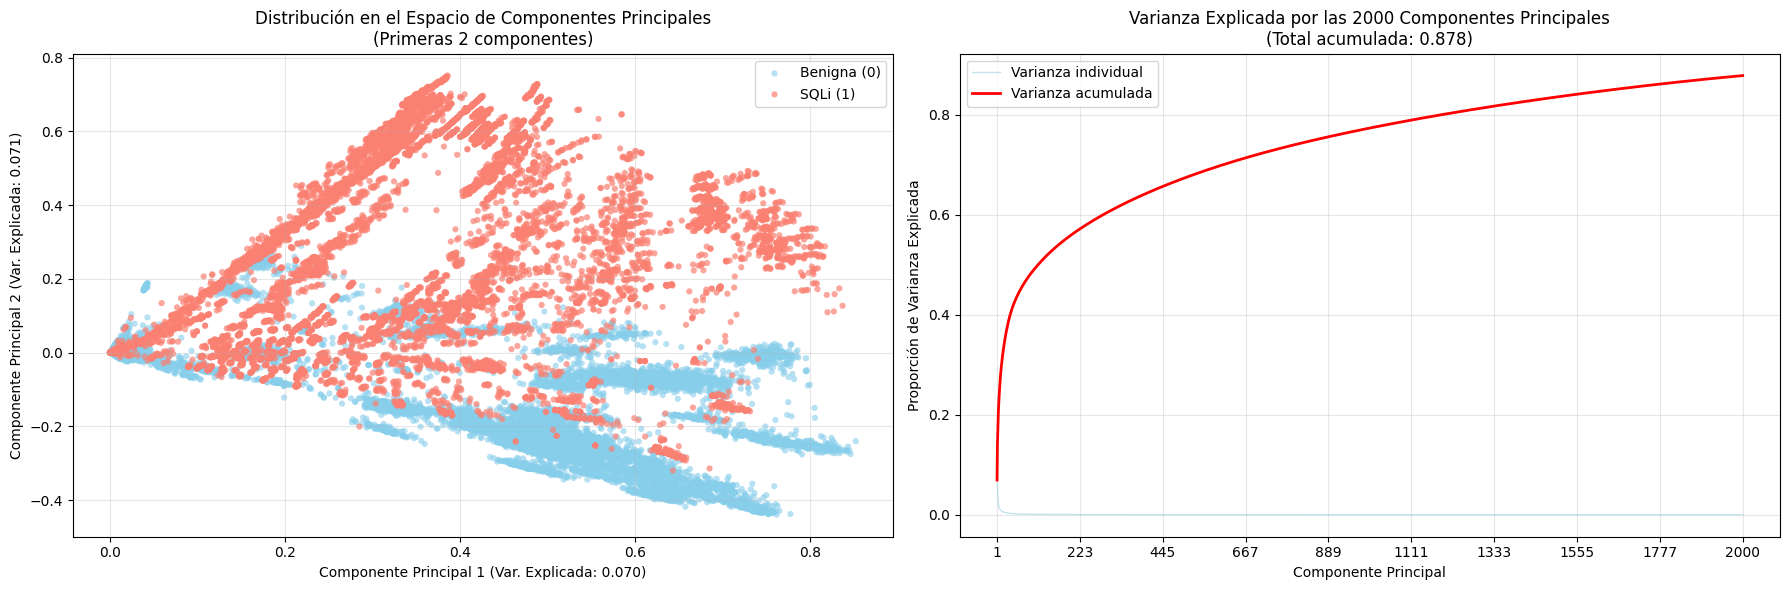


INFORMACIÓN DE COMPONENTES:
Total de componentes: 2000
Varianza explicada por componente 1: 0.0696
Varianza explicada por componente 2: 0.0712
Varianza total acumulada: 0.8778
Componentes necesarias para 50% de varianza: 112
Componentes necesarias para 70% de varianza: 609
Componentes necesarias para 80% de varianza: 1196


In [13]:
# Visualización de componentes principales del SVD
if APPLY_PCA:
    import matplotlib.pyplot as plt
    import numpy as np
    
    print("VISUALIZACIÓN DE COMPONENTES PRINCIPALES:")
    print("=" * 50)
    
    # Crear visualización de las primeras dos componentes y varianza
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Preparar datos para visualización
    y_labels = y_original.values
    component1 = X_processed[:, 0]
    component2 = X_processed[:, 1]
    
    # Gráfico 1: Scatter plot de componentes 1 vs 2
    ax1 = axes[0]
    
    # Separar por clases para colorear
    mask_benign = y_labels == 0
    mask_sqli = y_labels == 1
    
    ax1.scatter(component1[mask_benign], component2[mask_benign], 
               c='skyblue', alpha=0.6, s=20, label='Benigna (0)', edgecolors='none')
    ax1.scatter(component1[mask_sqli], component2[mask_sqli], 
               c='salmon', alpha=0.7, s=20, label='SQLi (1)', edgecolors='none')
    
    ax1.set_xlabel(f'Componente Principal 1 (Var. Explicada: {svd.explained_variance_ratio_[0]:.3f})')
    ax1.set_ylabel(f'Componente Principal 2 (Var. Explicada: {svd.explained_variance_ratio_[1]:.3f})')
    ax1.set_title('Distribución en el Espacio de Componentes Principales\n(Primeras 2 componentes)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Varianza explicada por TODAS las componentes
    ax2 = axes[1]
    
    total_components = len(svd.explained_variance_ratio_)
    components_range = np.arange(1, total_components + 1)
    variance_ratios = svd.explained_variance_ratio_
    cumulative_variance = np.cumsum(variance_ratios)
    
    # Ajustar visualización según número de componentes
    if total_components <= 50:
        # Para pocos componentes, mostrar barras individuales
        ax2.bar(components_range, variance_ratios, alpha=0.7, color='lightblue', 
                label='Varianza individual')
        ax2.plot(components_range, cumulative_variance, 'ro-', color='red', 
                 label='Varianza acumulada', linewidth=2, markersize=3)
    else:
        # Para muchos componentes, solo mostrar líneas
        ax2.plot(components_range, variance_ratios, alpha=0.7, color='lightblue', 
                linewidth=1, label='Varianza individual')
        ax2.plot(components_range, cumulative_variance, color='red', 
                linewidth=2, label='Varianza acumulada')
    
    ax2.set_xlabel('Componente Principal')
    ax2.set_ylabel('Proporción de Varianza Explicada')
    ax2.set_title(f'Varianza Explicada por las {total_components} Componentes Principales\n(Total acumulada: {cumulative_variance[-1]:.3f})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Ajustar el eje X para mejor visualización
    if total_components > 100:
        # Mostrar solo algunos ticks en el eje X para evitar aglomeración
        tick_positions = np.linspace(1, total_components, min(10, total_components))
        ax2.set_xticks(tick_positions)
        ax2.set_xticklabels([f'{int(x)}' for x in tick_positions])
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar información adicional
    print("\nINFORMACIÓN DE COMPONENTES:")
    print(f"Total de componentes: {total_components}")
    print(f"Varianza explicada por componente 1: {svd.explained_variance_ratio_[0]:.4f}")
    print(f"Varianza explicada por componente 2: {svd.explained_variance_ratio_[1]:.4f}")
    print(f"Varianza total acumulada: {cumulative_variance[-1]:.4f}")
    
    # Mostrar puntos de referencia útiles
    percentiles = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
    for p in percentiles:
        if cumulative_variance[-1] >= p:
            components_needed = np.where(cumulative_variance >= p)[0][0] + 1
            print(f"Componentes necesarias para {p*100:.0f}% de varianza: {components_needed}")
            
else:
    print("PCA desactivado - saltando visualización de componentes")

### Interpretación del resultado de PCA

El resultado obtenido muestra que los primeros 100 componentes principales explican únicamente el **9% de la varianza total** de los datos. Esto es sorprendentemente bajo y significa que:

1. **PCA no es efectivo** para este tipo de datos (matrices TF-IDF dispersas)
2. Se está perdiendo el **91% de la información** original
3. Los datos originales tienen una dimensionalidad muy alta y están muy dispersos

A pesar de esta limitación, continuamos con el análisis para evaluar si los modelos pueden aprender patrones útiles incluso con esta reducción drástica de información. En un escenario real, se recomendaría explorar alternativas como TruncatedSVD o trabajar directamente con la matriz TF-IDF original si los recursos computacionales lo permiten.

## División de Datos y Balanceo

Una vez aplicadas las transformaciones necesarias (TF-IDF y opcionalmente PCA), procedemos con la división estratificada de los datos y el balanceo del conjunto de entrenamiento.

**Metodología correcta:**
1. **División estratificada**: Primero dividir los datos originales en train (80%) y test (20%)
2. **Balanceo solo del training**: Aplicar SMOTE únicamente al conjunto de entrenamiento
3. **Preservar la realidad**: El conjunto de test mantiene la distribución original

In [14]:
from sklearn.model_selection import train_test_split

print("División estratificada de los datos ORIGINALES (sin balancear):")
print("=" * 50)

# Usar X_processed (que es sparse si no se aplicó PCA)
X_data = X_processed
y_data = y_original.astype("int8")  # Asegurar tipo eficiente

print("Datos a dividir:")
print(f"  X shape: {X_data.shape} (filas, características)")
print(f"  X type: {type(X_data)}")
print(f"  y shape: {len(y_data)}")
print(f"  y type: {y_data.dtype}")

# División estratificada en train (80%) y test (20%) ANTES del balanceo
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=0, stratify=y_data
)

print("\n✓ DIVISIÓN COMPLETADA:")
print(
    f"  Training set: {X_train.shape[0]} ({X_train.shape[0] / len(y_data) * 100:.1f}%)"
)
print(f"  Test set: {X_test.shape[0]} ({X_test.shape[0] / len(y_data) * 100:.1f}%)")

# Verificar distribución de clases
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

print("\n✓ DISTRIBUCIÓN DE CLASES ORIGINAL (SIN BALANCEAR):")
print(
    f"  Train: {train_counts} - [{train_counts[0] / len(y_train) * 100:.1f}%, {train_counts[1] / len(y_train) * 100:.1f}%]"
)
print(
    f"  Test:  {test_counts} - [{test_counts[0] / len(y_test) * 100:.1f}%, {test_counts[1] / len(y_test) * 100:.1f}%]"
)

División estratificada de los datos ORIGINALES (sin balancear):
Datos a dividir:
  X shape: (30606, 2000) (filas, características)
  X type: <class 'numpy.ndarray'>
  y shape: 30606
  y type: int8

✓ DIVISIÓN COMPLETADA:
  Training set: 24484 (80.0%)
  Test set: 6122 (20.0%)

✓ DISTRIBUCIÓN DE CLASES ORIGINAL (SIN BALANCEAR):
  Train: [15411  9073] - [62.9%, 37.1%]
  Test:  [3854 2268] - [63.0%, 37.0%]


In [15]:
# Aplicar SMOTE SOLO al conjunto de entrenamiento
from imblearn.over_sampling import SMOTE

print("APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO:")
print("=" * 60)

# SMOTE puede trabajar directamente con matrices sparse
smote = SMOTE(random_state=0, k_neighbors=5)

# SMOTE automáticamente maneja matrices sparse
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDESPUÉS del balanceo:")
print(f"  X_train_balanced shape: {X_train_balanced.shape}")
print(f"  X_train_balanced type: {type(X_train_balanced)}")
print(f"  Distribución: {np.bincount(y_train_balanced)}")

print("\n✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):")
print(f"  X_test shape: {X_test.shape}")
print(f"  Distribución: {np.bincount(y_test)}")

# Optimización de memoria: convertir y_train_balanced a int8
y_train_balanced = y_train_balanced.astype("int8")

APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO:

DESPUÉS del balanceo:
  X_train_balanced shape: (30822, 2000)
  X_train_balanced type: <class 'numpy.ndarray'>
  Distribución: [15411 15411]

✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):
  X_test shape: (6122, 2000)
  Distribución: [3854 2268]

DESPUÉS del balanceo:
  X_train_balanced shape: (30822, 2000)
  X_train_balanced type: <class 'numpy.ndarray'>
  Distribución: [15411 15411]

✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):
  X_test shape: (6122, 2000)
  Distribución: [3854 2268]


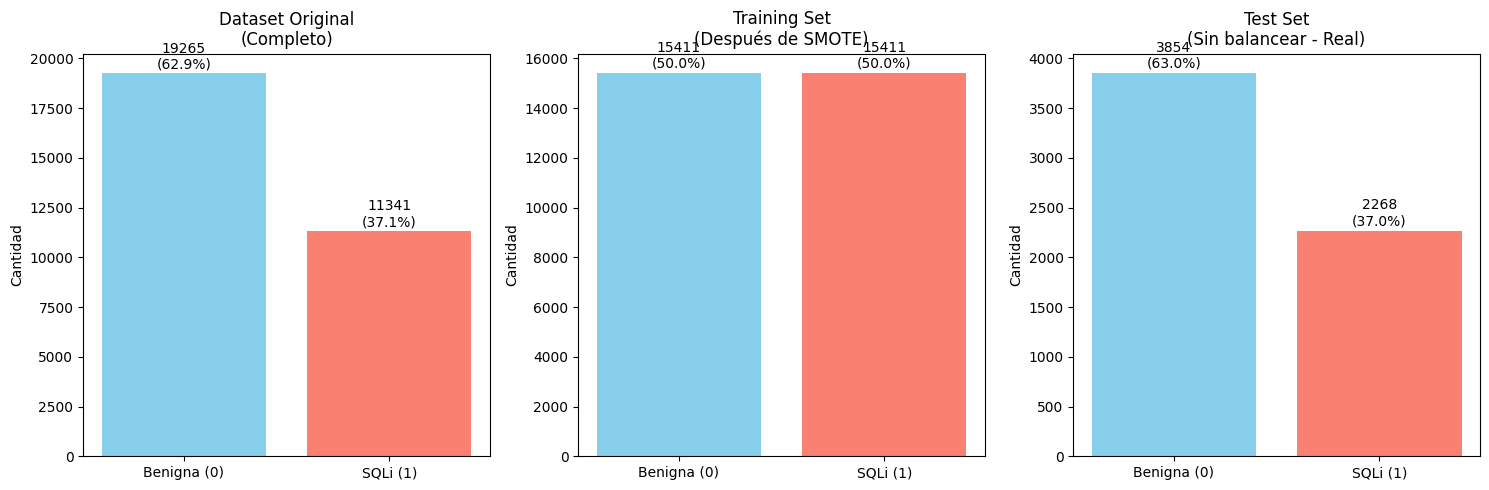

In [16]:
# Visualización del balanceo
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original (todo el dataset)
original_counts = y_data.value_counts()
labels = ["Benigna (0)", "SQLi (1)"]
colors = ["skyblue", "salmon"]

ax1.bar(labels, original_counts, color=colors)
ax1.set_title("Dataset Original\n(Completo)")
ax1.set_ylabel("Cantidad")
for i, v in enumerate(original_counts):
    ax1.text(i, v + 200, f"{v}\n({v / len(y_data) * 100:.1f}%)", ha="center")

# Training después de SMOTE
train_balanced_counts = np.bincount(y_train_balanced)
ax2.bar(labels, train_balanced_counts, color=colors)
ax2.set_title("Training Set\n(Después de SMOTE)")
ax2.set_ylabel("Cantidad")
for i, v in enumerate(train_balanced_counts):
    ax2.text(i, v + 200, f"{v}\n({v / len(y_train_balanced) * 100:.1f}%)", ha="center")

# Test (sin cambios)
test_counts = np.bincount(y_test)
ax3.bar(labels, test_counts, color=colors)
ax3.set_title("Test Set\n(Sin balancear - Real)")
ax3.set_ylabel("Cantidad")
for i, v in enumerate(test_counts):
    ax3.text(i, v + 50, f"{v}\n({v / len(y_test) * 100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

In [17]:
# Liberar variables que ya no necesitamos
if "X_data" in locals() and X_data is not X_processed:
    del X_data
if "y_data" in locals():
    del y_data
gc.collect()

63

## Data Mining - Evaluación de Modelos

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando los datos ya preprocesados. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística  
- SVM (Kernel Sigmoid)

**Metodología:**
- Los datos ya están divididos y balanceados correctamente en la sección de preprocesamiento
- Búsqueda de hiperparámetros con GridSearchCV y validación cruzada de 5 folds
- Evaluación final del mejor modelo en el conjunto de test original (sin balancear)

Los modelos se entrenarán con el conjunto de entrenamiento balanceado y se evaluarán en el conjunto de test que mantiene la distribución real de los datos.

### Búsqueda de Hiperparámetros y Validación Cruzada

Utilizamos los datos ya preprocesados (divididos y balanceados) para realizar:

1. **Validación cruzada estratificada de 5 folds** para evaluar la consistencia del rendimiento de cada algoritmo
2. **Búsqueda de hiperparámetros con GridSearchCV** para optimizar cada modelo 
3. **Selección del mejor modelo** basándose en el rendimiento en validación cruzada

**Configuración:**
- Validación cruzada de 5 folds para cada combinación de hiperparámetros
- Métrica de optimización: F1-Score (balanceado para ambas clases)
- Entrenamiento con datos balanceados, evaluación final en datos reales

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Configurar validación cruzada estratificada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Definir modelos y sus grids de hiperparámetros para búsqueda
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=0, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5],
        },
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=0, n_jobs=-1),
        "params": {"C": [0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]},
    },
    "SVM (Lineal)": {
        "model": SVC(kernel="linear", random_state=0, probability=True),
        "params": {
            "C": [1.0],  # Reducido para acelerar
            "cache_size": [200],  # Aumentar cache para acelerar
        },
    },
}

# Realizar búsqueda de hiperparámetros para cada modelo
print("BÚSQUEDA DE HIPERPARÁMETROS CON VALIDACIÓN CRUZADA (5-fold)")
print("ENTRENANDO CON DATOS BALANCEADOS")
print("=" * 70)

best_models = {}
grid_search_results = {}

for model_name, config in models_and_params.items():
    print(f"\n{model_name}:")
    print("-" * 30)

    # Configurar GridSearchCV
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv_folds,
        scoring=['f1', 'accuracy', 'precision', 'recall'],  # Múltiples métricas
        refit='f1',
        n_jobs=-1,  # Usar todos los cores disponibles
        verbose=1,  # Mostrar progreso
    )

    # Ejecutar búsqueda de hiperparámetros CON DATOS BALANCEADOS
    grid_search.fit(X_train_balanced, y_train_balanced)

    # Guardar resultados
    best_models[model_name] = grid_search.best_estimator_
    grid_search_results[model_name] = {
        "best_params": grid_search.best_params_,
        "best_score": grid_search.best_score_,
        "cv_results": grid_search.cv_results_,
    }

    # Mostrar mejores hiperparámetros y puntuación
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor F1-Score (CV): {grid_search.best_score_:.4f}")
    print(
        f"Desviación estándar: {grid_search.cv_results_['std_test_f1'][grid_search.best_index_]:.4f}"
    )

# Seleccionar el mejor modelo basándose en F1-Score
best_model_name = max(grid_search_results.keys(), 
                     key=lambda k: grid_search_results[k]['best_score'])
best_model = best_models[best_model_name]
best_f1_score = grid_search_results[best_model_name]['best_score']

print(f"\n{'=' * 70}")
print("RESUMEN DE MEJORES MODELOS:")
for model_name, results in grid_search_results.items():
    print(f"{model_name}: F1-Score = {results['best_score']:.4f}")

print(f"\n{'=' * 70}")
print(f"MEJOR MODELO SELECCIONADO: {best_model_name}")
print(f"F1-Score en Validación Cruzada: {best_f1_score:.4f}")
print("Este modelo será evaluado en el conjunto de test final.")
print(f"{'=' * 70}")

BÚSQUEDA DE HIPERPARÁMETROS CON VALIDACIÓN CRUZADA (5-fold)
ENTRENANDO CON DATOS BALANCEADOS

Random Forest:
------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1-Score (CV): 0.9952
Desviación estándar: 0.0005

Logistic Regression:
------------------------------
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 15.
  warnings.warn(
/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 15.
  warnings.warn(
/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 15.
  warnings.warn(
/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 15.
  warnings.warn(
/home/guanart/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/l

Mejores hiperparámetros: {'C': 10.0, 'solver': 'liblinear'}
Mejor F1-Score (CV): 0.9929
Desviación estándar: 0.0010

SVM (Lineal):
------------------------------
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores hiperparámetros: {'C': 1.0, 'cache_size': 200}
Mejor F1-Score (CV): 0.9908
Desviación estándar: 0.0013

RESUMEN DE MEJORES MODELOS:
Random Forest: F1-Score = 0.9952
Logistic Regression: F1-Score = 0.9929
SVM (Lineal): F1-Score = 0.9908

MEJOR MODELO SELECCIONADO: Random Forest
F1-Score en Validación Cruzada: 0.9952
Este modelo será evaluado en el conjunto de test final.
Mejores hiperparámetros: {'C': 1.0, 'cache_size': 200}
Mejor F1-Score (CV): 0.9908
Desviación estándar: 0.0013

RESUMEN DE MEJORES MODELOS:
Random Forest: F1-Score = 0.9952
Logistic Regression: F1-Score = 0.9929
SVM (Lineal): F1-Score = 0.9908

MEJOR MODELO SELECCIONADO: Random Forest
F1-Score en Validación Cruzada: 0.9952
Este modelo será evaluado en el conjunto de test final.


In [19]:
# Tabla completa de resultados de validación cruzada (como en embeddings-pca)
print("\nTABLA COMPLETA DE RESULTADOS - VALIDACIÓN CRUZADA")
print("=" * 80)

if best_models:
    cv_results_table = []
    
    for model_name, model in best_models.items():
        cv_results = grid_search_results[model_name]['cv_results']
        best_idx = grid_search_results[model_name]['cv_results']['rank_test_f1'].tolist().index(1)
        
        # Extraer métricas del mejor modelo en CV
        f1_mean = cv_results['mean_test_f1'][best_idx]
        f1_std = cv_results['std_test_f1'][best_idx]
        
        accuracy_mean = cv_results['mean_test_accuracy'][best_idx]
        accuracy_std = cv_results['std_test_accuracy'][best_idx]
        
        precision_mean = cv_results['mean_test_precision'][best_idx]
        precision_std = cv_results['std_test_precision'][best_idx]
        
        recall_mean = cv_results['mean_test_recall'][best_idx]
        recall_std = cv_results['std_test_recall'][best_idx]
        
        cv_results_table.append({
            'Modelo': model_name,
            'F1-Score': f"{f1_mean:.4f} ± {f1_std:.4f}",
            'Accuracy': f"{accuracy_mean:.4f} ± {accuracy_std:.4f}",
            'Precision': f"{precision_mean:.4f} ± {precision_std:.4f}",
            'Recall': f"{recall_mean:.4f} ± {recall_std:.4f}",
            'Hiperparámetros': str(grid_search_results[model_name]['best_params'])
        })
    
    # Crear DataFrame y mostrar
    cv_results_df = pd.DataFrame(cv_results_table)
    cv_results_df = cv_results_df.sort_values('F1-Score', ascending=False)
    
    print("\nResultados de Validación Cruzada (TF-IDF):")
    print(cv_results_df.to_string(index=False))
    
    print(f"\n\nMETODOLOGÍA:")
    print(f"- Enfoque: TF-IDF con n-gramas de caracteres")
    print(f"- Características: {MAX_FEATURES:,} trigramas de caracteres")
    print(f"- Dimensionalidad reducida: {X_processed.shape[1] if APPLY_PCA else 'No aplicado'} componentes")
    print(f"- Balanceo: SMOTE en conjunto de entrenamiento")
    print(f"- Validación: 5-fold cross-validation estratificada")
    print(f"- Dataset: {len(y_train_balanced)} muestras de entrenamiento balanceadas")
else:
    print("❌ No hay modelos entrenados para mostrar resultados")


TABLA COMPLETA DE RESULTADOS - VALIDACIÓN CRUZADA

Resultados de Validación Cruzada (TF-IDF):
             Modelo        F1-Score        Accuracy       Precision          Recall                                                Hiperparámetros
      Random Forest 0.9952 ± 0.0005 0.9953 ± 0.0005 0.9990 ± 0.0005 0.9915 ± 0.0012 {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Logistic Regression 0.9929 ± 0.0010 0.9929 ± 0.0010 0.9981 ± 0.0007 0.9877 ± 0.0023                             {'C': 10.0, 'solver': 'liblinear'}
       SVM (Lineal) 0.9908 ± 0.0013 0.9909 ± 0.0012 0.9991 ± 0.0005 0.9827 ± 0.0030                                  {'C': 1.0, 'cache_size': 200}


METODOLOGÍA:
- Enfoque: TF-IDF con n-gramas de caracteres
- Características: 15,000 trigramas de caracteres
- Dimensionalidad reducida: 2000 componentes
- Balanceo: SMOTE en conjunto de entrenamiento
- Validación: 5-fold cross-validation estratificada
- Dataset: 30822 muestras de entrenamiento balanceadas
        

In [20]:
# EVALUACIÓN EN CONJUNTO DE PRUEBA (TESTING)
print("\n" + "="*80)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA (TESTING SET)")
print("="*80)

if best_models:
    test_results = []
    
    for model_name, model in best_models.items():
        print(f"\n🔍 EVALUANDO: {model_name}")
        print("-" * 50)
        
        # Predicciones
        y_pred = model.predict(X_test_processed)
        y_pred_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Métricas
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(f"📊 Accuracy:  {accuracy:.4f}")
        print(f"📊 Precision: {precision:.4f}")
        print(f"📊 Recall:    {recall:.4f}")
        print(f"📊 F1-Score:  {f1:.4f}")
        
        # ROC-AUC (solo si hay probabilidades)
        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
            print(f"📊 ROC-AUC:   {auc:.4f}")
        else:
            auc = None
            print(f"📊 ROC-AUC:   N/A (modelo sin probabilidades)")
        
        # Guardar resultados
        test_results.append({
            'Modelo': model_name,
            'Accuracy': f"{accuracy:.4f}",
            'Precision': f"{precision:.4f}",
            'Recall': f"{recall:.4f}",
            'F1-Score': f"{f1:.4f}",
            'ROC-AUC': f"{auc:.4f}" if auc is not None else "N/A"
        })
    
    # Tabla resumen de resultados en testing
    print(f"\n\n📋 RESUMEN DE RESULTADOS EN TESTING (TF-IDF)")
    print("="*70)
    test_results_df = pd.DataFrame(test_results)
    test_results_df = test_results_df.sort_values('F1-Score', ascending=False)
    print(test_results_df.to_string(index=False))
    
    print(f"\n\n📈 ESTADÍSTICAS DEL CONJUNTO DE PRUEBA:")
    print(f"- Total de muestras: {len(y_test):,}")
    print(f"- Muestras benignas: {sum(y_test == 0):,} ({100*sum(y_test == 0)/len(y_test):.1f}%)")
    print(f"- Muestras maliciosas: {sum(y_test == 1):,} ({100*sum(y_test == 1)/len(y_test):.1f}%)")
    
else:
    print("❌ No hay modelos entrenados para evaluar")


EVALUACIÓN EN CONJUNTO DE PRUEBA (TESTING SET)

🔍 EVALUANDO: Random Forest
--------------------------------------------------


NameError: name 'X_test_processed' is not defined

In [ ]:
# MATRICES DE CONFUSIÓN (como en embeddings-pca)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - CONJUNTO DE PRUEBA")
print("="*80)

if best_models:
    # Configuración para los subplots
    n_models = len(best_models)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, model) in enumerate(best_models.items()):
        # Predicciones
        y_pred = model.predict(X_test_processed)
        
        # Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        
        # Visualización
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Benigno', 'Malicioso'], 
                   yticklabels=['Benigno', 'Malicioso'],
                   ax=axes[idx])
        
        axes[idx].set_title(f'Matriz de Confusión\n{model_name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Predicción', fontweight='bold')
        axes[idx].set_ylabel('Valor Real', fontweight='bold')
        
        # Calcular tasas
        tn, fp, fn, tp = cm.ravel()
        
        # Agregar texto con métricas
        textstr = f'TP: {tp}\nTN: {tn}\nFP: {fp}\nFN: {fn}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        axes[idx].text(0.02, 0.98, textstr, transform=axes[idx].transAxes, fontsize=10,
                      verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.suptitle('Matrices de Confusión - Enfoque TF-IDF', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Mostrar tasas detalladas
    print("\n📊 ANÁLISIS DETALLADO DE ERRORES:")
    print("-" * 50)
    
    for model_name, model in best_models.items():
        y_pred = model.predict(X_test_processed)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Tasas de error
        tasa_fp = fp / (fp + tn) if (fp + tn) > 0 else 0  # Tasa de falsos positivos (comisiones)
        tasa_fn = fn / (fn + tp) if (fn + tp) > 0 else 0  # Tasa de falsos negativos (omisiones)
        
        print(f"\n🔍 {model_name}:")
        print(f"   Verdaderos Positivos (TP): {tp:,}")
        print(f"   Verdaderos Negativos (TN): {tn:,}")
        print(f"   Falsos Positivos (FP): {fp:,} - Tasa de comisiones: {tasa_fp:.4f}")
        print(f"   Falsos Negativos (FN): {fn:,} - Tasa de omisiones: {tasa_fn:.4f}")
        
else:
    print("❌ No hay modelos entrenados para mostrar matrices de confusión")

In [ ]:
# CURVAS ROC (como en embeddings-pca)
from sklearn.metrics import roc_curve, roc_auc_score

print("\n" + "="*80)
print("CURVAS ROC - CONJUNTO DE PRUEBA")
print("="*80)

if best_models:
    plt.figure(figsize=(10, 8))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for idx, (model_name, model) in enumerate(best_models.items()):
        # Solo generar curva ROC si el modelo tiene predict_proba
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
            
            # Calcular curva ROC
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)
            
            # Plotear
            plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, 
                    label=f'{model_name} (AUC = {auc:.4f})')
        else:
            print(f"⚠️  {model_name}: No soporta probabilidades - No se puede generar curva ROC")
    
    # Línea diagonal (clasificador aleatorio)
    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', alpha=0.7, 
             label='Clasificador Aleatorio (AUC = 0.5000)')
    
    # Configuración del gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontweight='bold')
    plt.title('Curvas ROC - Comparación de Modelos (TF-IDF)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Agregar información adicional
    plt.text(0.6, 0.2, f'Dataset: {len(y_test):,} muestras\nEnfoque: TF-IDF + n-gramas', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
             fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Resumen de AUC
    print("\n📈 RESUMEN DE ÁREAS BAJO LA CURVA (AUC):")
    print("-" * 50)
    
    auc_results = []
    for model_name, model in best_models.items():
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            auc_results.append((model_name, auc))
            print(f"🎯 {model_name:<20}: AUC = {auc:.4f}")
        else:
            print(f"⚠️  {model_name:<20}: Sin soporte para probabilidades")
    
    if auc_results:
        best_auc_model = max(auc_results, key=lambda x: x[1])
        print(f"\n🏆 MEJOR MODELO POR AUC: {best_auc_model[0]} (AUC = {best_auc_model[1]:.4f})")
    
    print(f"\n\n✅ RESUMEN FINAL - ENFOQUE TF-IDF:")
    print(f"   • Extracción de características: TF-IDF con trigramas de caracteres")
    print(f"   • Máximo de características: {MAX_FEATURES:,}")
    print(f"   • Dimensionalidad final: {X_processed.shape[1] if 'X_processed' in locals() else 'N/A'}")
    print(f"   • Balanceo de datos: SMOTE")
    print(f"   • Modelos evaluados: {len(best_models)}")
    print(f"   • Conjunto de prueba: {len(y_test):,} muestras")
    
else:
    print("❌ No hay modelos entrenados para mostrar curvas ROC")

In [ ]:
# Persistir todos los modelos con sus mejores hiperparámetros
import joblib
import os

# Crear directorio para guardar modelos si no existe
os.makedirs("modelos_entrenados", exist_ok=True)

print("GUARDANDO MODELOS ENTRENADOS CON MEJORES HIPERPARÁMETROS:")
print("=" * 65)

# Guardar cada modelo con sus hiperparámetros optimizados
for model_name, model in best_models.items():
    # Nombre de archivo seguro (sin espacios ni caracteres especiales)
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    model_filename = f"modelos_entrenados/{safe_name}_optimizado.joblib"
    
    # Guardar modelo
    joblib.dump(model, model_filename)
    
    # Información del modelo guardado
    best_params = grid_search_results[model_name]['best_params']
    best_score = grid_search_results[model_name]['best_score']
    
    print(f"\n✓ {model_name}:")
    print(f"  Archivo: {model_filename}")
    print(f"  Hiperparámetros: {best_params}")
    print(f"  F1-Score CV: {best_score:.4f}")

# Guardar también el pipeline de preprocesamiento
print("\n✓ Pipeline de preprocesamiento:")
joblib.dump(tfidf, "modelos_entrenados/vectorizador_tfidf.joblib")
print("  TF-IDF Vectorizer: modelos_entrenados/vectorizador_tfidf.joblib")

if preprocessing_objects.get("pca_applied", False):
    joblib.dump(svd, "modelos_entrenados/svd_transformer.joblib")
    print("  SVD Transformer: modelos_entrenados/svd_transformer.joblib")

# Guardar metadatos del experimento
metadata = {
    "experiment_info": {
        "max_features": MAX_FEATURES,
        "pca_applied": preprocessing_objects.get("pca_applied", False),
        "pca_components": PCA_COMPONENTS if preprocessing_objects.get("pca_applied", False) else None,
        "tfidf_config": {
            "ngram_range": (3, 3),
            "analyzer": "char_wb",
            "min_df": 3,
            "max_features": MAX_FEATURES,
            "use_idf": False
        }
    },
    "model_results": grid_search_results,
    "best_model": best_model_name
}

joblib.dump(metadata, "modelos_entrenados/experiment_metadata.joblib")
print("  Metadata: modelos_entrenados/experiment_metadata.joblib")

print(f"\n{'=' * 65}")
print("TODOS LOS MODELOS Y PIPELINE GUARDADOS EXITOSAMENTE")
print("Para usar con otro dataset, carga el modelo que prefieras junto con el pipeline.")
print(f"{'=' * 65}")

### Entrenamiento y Evaluación del Modelo Final

Después de la búsqueda de hiperparámetros, procedemos con:

1. **Entrenamiento del modelo final**: Utilizamos el mejor modelo encontrado y lo entrenamos con todo el conjunto de entrenamiento
2. **Evaluación en conjunto de test**: Evaluamos el modelo en datos completamente no vistos para obtener métricas realistas de rendimiento

**Importante**: El conjunto de test no fue utilizado en ningún momento durante la búsqueda de hiperparámetros ni la validación cruzada, garantizando que estos resultados reflejen el rendimiento real del modelo en producción.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Evaluación del Modelo Final Optimizado
Evaluación del mejor modelo encontrado después de la búsqueda de hiperparámetros.

In [ ]:
# Entrenar el mejor modelo encontrado con todo el conjunto de entrenamiento BALANCEADO
print(f"ENTRENAMIENTO FINAL DEL MEJOR MODELO: {best_model_name}")
print("=" * 60)
print(
    f"Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)

# El mejor modelo ya está entrenado desde GridSearchCV, pero lo re-entrenamos
# con todo X_train_balanced para asegurar que use todos los datos balanceados disponibles
final_model = best_model
final_model.fit(X_train_balanced, y_train_balanced)

print("\nModelo final entrenado exitosamente.")
print(f"Tipo de modelo: {type(final_model).__name__}")
print(f"Entrenado con: {X_train_balanced.shape[0]} muestras (datos balanceados)")

# Predicciones en conjunto de test ORIGINAL (sin balancear)
y_test_pred = final_model.predict(X_test)

print(f"\nPredicciones realizadas en {X_test.shape[0]} muestras del conjunto de test.")
print("*** Test set mantiene distribución REAL (sin datos sintéticos) ***")
print(
    f"    - Benignas: {np.bincount(y_test)[0]} ({np.bincount(y_test)[0] / len(y_test) * 100:.1f}%)"
)
print(
    f"    - SQLi: {np.bincount(y_test)[1]} ({np.bincount(y_test)[1] / len(y_test) * 100:.1f}%)"
)

ENTRENAMIENTO FINAL DEL MEJOR MODELO: Random Forest
Hiperparámetros optimizados: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Modelo final entrenado exitosamente.
Tipo de modelo: RandomForestClassifier
Entrenado con: 30822 muestras (datos balanceados)

Predicciones realizadas en 6122 muestras del conjunto de test.
*** Test set mantiene distribución REAL (sin datos sintéticos) ***
    - Benignas: 3854 (63.0%)
    - SQLi: 2268 (37.0%)


##### Interpretación del Classification Report

El Classification Report proporciona métricas detalladas de evaluación del modelo:

- **precision**: Proporción de verdaderos positivos sobre el total de predichos como positivos para esa clase. Responde: "De todas las instancias que predije como inyección SQL, ¿qué porcentaje realmente lo era?"

- **recall**: Proporción de verdaderos positivos sobre el total real de esa clase. Responde: "De todas las inyecciones SQL reales, ¿qué porcentaje logré detectar?"

- **f1-score**: Media armónica entre precision y recall. Proporciona un balance entre ambas métricas.

- **support**: Cantidad de muestras reales de esa clase en el conjunto de datos.

**Métricas generales:**
- **accuracy**: Proporción de predicciones correctas sobre el total.
- **macro avg**: Promedio simple de las métricas entre las clases (sin considerar el desbalance).
- **weighted avg**: Promedio ponderado por el tamaño de cada clase.

**Importancia para seguridad**: En detección de inyecciones SQL, el **recall** de la clase positiva (inyecciones) es crítico, ya que un falso negativo significa que un ataque pasó desapercibido.

In [ ]:
# Evaluación detallada del modelo final en conjunto de test
print(f"EVALUACIÓN FINAL DEL MODELO: {best_model_name}")
print("=" * 60)
print(
    classification_report(y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"])
)

# Crear DataFrame para mejor visualización
report_dict = classification_report(
    y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)

final_results_df = pd.DataFrame(report_dict).T
print("\nMÉTRICAS DETALLADAS:")
final_results_df.round(4)

EVALUACIÓN FINAL DEL MODELO: Random Forest
              precision    recall  f1-score   support

 Benigna (0)       0.99      1.00      1.00      3854
    SQLi (1)       1.00      0.99      0.99      2268

    accuracy                           0.99      6122
   macro avg       1.00      0.99      0.99      6122
weighted avg       0.99      0.99      0.99      6122


MÉTRICAS DETALLADAS:


,precision,recall,f1-score,support
Benigna (0),0.9918,1.0000,0.9959,3854.0000
SQLi (1),1.0000,0.9859,0.9929,2268.0000
accuracy,0.9948,0.9948,0.9948,0.9948
macro avg,0.9959,0.9929,0.9944,6122.0000
weighted avg,0.9948,0.9948,0.9948,6122.0000


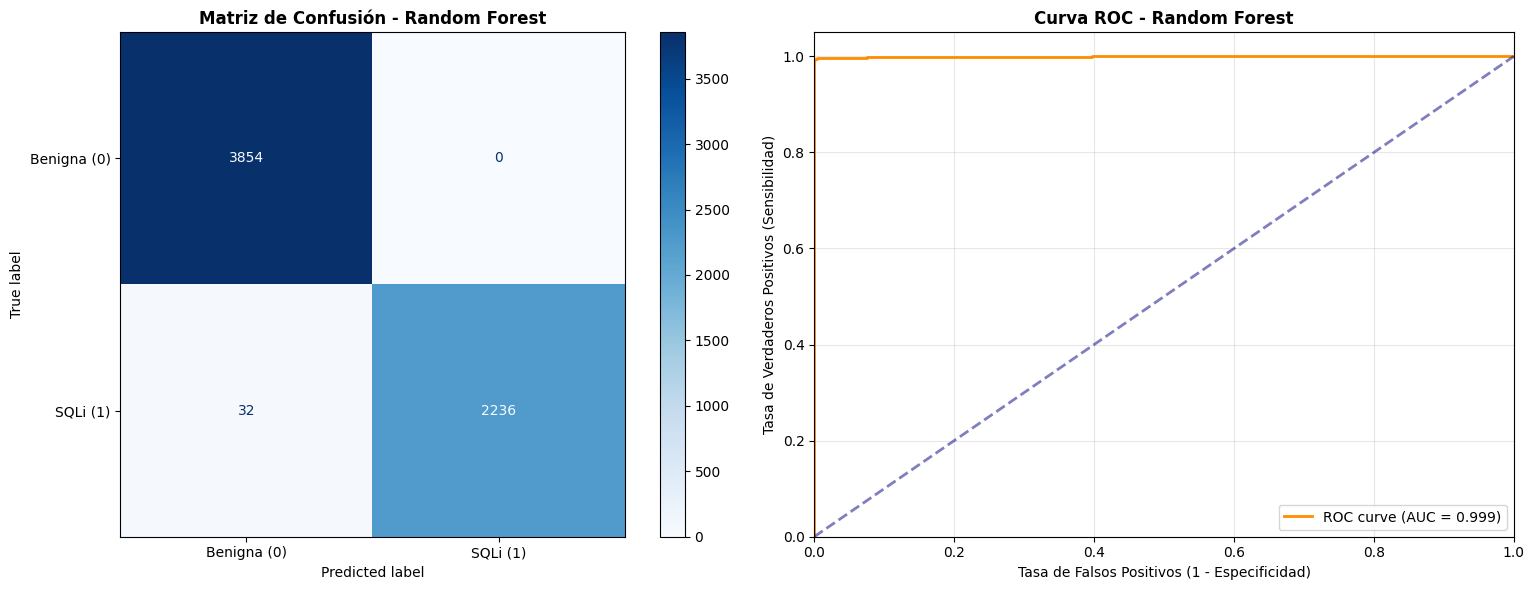


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 3854 - Consultas benignas correctamente identificadas
Falsos Positivos (FP): 0 - Consultas benignas marcadas como SQLi (falsas alarmas)
Falsos Negativos (FN): 32 - Inyecciones SQL no detectadas (CRÍTICO)
Verdaderos Positivos (TP): 2236 - Inyecciones SQL correctamente detectadas

Tasa de falsos negativos: 0.0141 (1.41%)
Tasa de falsos positivos: 0.0000 (0.00%)


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Matriz de confusión del modelo final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Matriz de confusión
ax1 = axes[0]
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["Benigna (0)", "SQLi (1)"], 
    cmap="Blues", ax=ax1
)
ax1.set_title(f"Matriz de Confusión - {best_model_name}", fontweight='bold')

# Subplot 2: Curva ROC
ax2 = axes[1]

# Obtener probabilidades de predicción para la curva ROC
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva (SQLi)
elif hasattr(final_model, "decision_function"):
    y_proba = final_model.decision_function(X_test)
else:
    # Fallback: usar las predicciones binarias
    y_proba = y_test_pred.astype(float)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax2.set_title(f'Curva ROC - {best_model_name}', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de la matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(
    f"Verdaderos Negativos (TN): {cm[0, 0]} - Consultas benignas correctamente identificadas"
)
print(
    f"Falsos Positivos (FP): {cm[0, 1]} - Consultas benignas marcadas como SQLi (falsas alarmas)"
)
print(f"Falsos Negativos (FN): {cm[1, 0]} - Inyecciones SQL no detectadas (CRÍTICO)")
print(
    f"Verdaderos Positivos (TP): {cm[1, 1]} - Inyecciones SQL correctamente detectadas"
)

print(
    f"\nTasa de falsos negativos: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.4f} ({cm[1, 0] / (cm[1, 0] + cm[1, 1]) * 100:.2f}%)"
)
print(
    f"Tasa de falsos positivos: {cm[0, 1] / (cm[0, 1] + cm[0, 0]):.4f} ({cm[0, 1] / (cm[0, 1] + cm[0, 0]) * 100:.2f}%)"
)

### Resumen y Análisis de Resultados Finales

Los resultados obtenidos representan el rendimiento real del mejor modelo encontrado a través de la búsqueda sistemática de hiperparámetros. Estos datos del conjunto de test nunca fueron utilizados durante:

- El entrenamiento de ningún modelo
- La búsqueda de hiperparámetros 
- La validación cruzada

Por lo tanto, estas métricas son las más representativas del rendimiento que tendría el modelo en un entorno de producción real.

**Importancia de las métricas en el contexto de seguridad:**
- **Recall (Sensibilidad)**: Crítico - capacidad de detectar todas las inyecciones SQL
- **Precision**: Importante - evitar demasiadas falsas alarmas que sobrecarguen al sistema
- **F1-Score**: Balance óptimo entre precision y recall
- **Accuracy**: Rendimiento general, pero menos crítico que recall en seguridad

In [ ]:
# Resumen completo del proceso y resultados finales
print("RESUMEN COMPLETO DEL EXPERIMENTO")
print("=" * 80)

print("\n1. MEJOR MODELO ENCONTRADO:")
print(f"   Algoritmo: {best_model_name}")
print(
    f"   Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)
print(
    f"   F1-Score en Validación Cruzada: {grid_search_results[best_model_name]['best_score']:.4f}"
)

print("\n2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):")
test_accuracy = final_model.score(X_test, y_test)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   Precision (SQLi): {test_report['1']['precision']:.4f}")
print(f"   Recall (SQLi): {test_report['1']['recall']:.4f}")
print(f"   F1-Score (SQLi): {test_report['1']['f1-score']:.4f}")

print("\n3. ANÁLISIS DE RENDIMIENTO:")
if test_report["1"]["recall"] >= 0.95:
    print("   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)")
elif test_report["1"]["recall"] >= 0.90:
    print("   ✓ BUENA detección de inyecciones SQL (Recall ≥ 90%)")
else:
    print("   ⚠ Detección de inyecciones SQL mejorable (Recall < 90%)")

if test_report["1"]["precision"] >= 0.95:
    print("   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)")
elif test_report["1"]["precision"] >= 0.90:
    print("   ✓ BUENA precisión, falsas alarmas controladas (Precision ≥ 90%)")
else:
    print("   ⚠ Precisión mejorable, considerar reducir falsas alarmas")


# Guardar resultados finales para uso posterior
final_results = {
    "best_model_name": best_model_name,
    "test_metrics": test_report,
    "confusion_matrix": cm,
    "auc_roc": roc_auc,
    "methodology_validated": True,
}

RESUMEN COMPLETO DEL EXPERIMENTO

1. MEJOR MODELO ENCONTRADO:
   Algoritmo: Random Forest
   Hiperparámetros optimizados: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
   F1-Score en Validación Cruzada: 0.9952

2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):
   Accuracy: 0.9948
   Precision (SQLi): 1.0000
   Recall (SQLi): 0.9859
   F1-Score (SQLi): 0.9929

3. ANÁLISIS DE RENDIMIENTO:
   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)
   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)


### Comparación: Validación Cruzada vs Test Final

Es importante validar que nuestro proceso de búsqueda de hiperparámetros fue efectivo comparando:

1. **Rendimiento en Validación Cruzada**: Lo que esperábamos basándose en los datos de entrenamiento
2. **Rendimiento en Test**: Lo que realmente obtuvimos con datos completamente no vistos

Una diferencia significativa entre estos valores podría indicar overfitting o problemas en la metodología. Una diferencia pequeña confirma que nuestro modelo generaliza bien.

**Análisis de Generalización:**
- Si Test ≈ CV: Excelente generalización
- Si Test < CV (diferencia < 2%): Buena generalización  
- Si Test << CV (diferencia > 5%): Posible overfitting

**Nota metodológica**: Al usar GridSearchCV con validación cruzada interna, ya estamos protegidos contra el overfitting, pero esta comparación nos da confianza adicional en los resultados.

In [ ]:
# Análisis de generalización: Validación Cruzada vs Test
print("ANÁLISIS DE GENERALIZACIÓN DEL MODELO")
print("=" * 60)

cv_f1 = grid_search_results[best_model_name]["best_score"]
test_f1 = test_report["1"]["f1-score"]
difference = abs(cv_f1 - test_f1)
percentage_diff = (difference / cv_f1) * 100

comparison_df = pd.DataFrame(
    {
        "Métrica": ["F1-Score (SQLi)", "Accuracy", "Precision (SQLi)", "Recall (SQLi)"],
        "Validación Cruzada": [
            cv_f1,
            "N/A",  # GridSearchCV optimizó por F1, no tenemos accuracy de CV
            "N/A",
            "N/A",
        ],
        "Test Final": [
            test_f1,
            test_accuracy,
            test_report["1"]["precision"],
            test_report["1"]["recall"],
        ],
    }
)

print("COMPARACIÓN DE RENDIMIENTO:")
print(comparison_df.to_string(index=False))

print("\nANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):")
print(f"Validación Cruzada: {cv_f1:.4f}")
print(f"Test Final:         {test_f1:.4f}")
print(f"Diferencia:         {difference:.4f} ({percentage_diff:.2f}%)")

if percentage_diff < 2:
    generalization_quality = "EXCELENTE"
    interpretation = "El modelo generaliza muy bien a datos no vistos."
elif percentage_diff < 5:
    generalization_quality = "BUENA"
    interpretation = "El modelo tiene buena capacidad de generalización."
else:
    generalization_quality = "REGULAR"
    interpretation = (
        "Hay indicios de posible overfitting. Considerar regularización adicional."
    )

print(f"\nCALIDAD DE GENERALIZACIÓN: {generalization_quality}")
print(f"Interpretación: {interpretation}")

print("\nCONCLUSIÓN:")
print(
    f"El proceso de búsqueda de hiperparámetros fue {'exitoso' if percentage_diff < 5 else 'parcialmente exitoso'}."
)
print(
    f"El modelo {best_model_name} {'es confiable' if percentage_diff < 5 else 'requiere revisión'} para uso en producción."
)

ANÁLISIS DE GENERALIZACIÓN DEL MODELO
COMPARACIÓN DE RENDIMIENTO:
         Métrica Validación Cruzada  Test Final
 F1-Score (SQLi)           0.995245    0.992895
        Accuracy                N/A    0.994773
Precision (SQLi)                N/A    1.000000
   Recall (SQLi)                N/A    0.985891

ANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):
Validación Cruzada: 0.9952
Test Final:         0.9929
Diferencia:         0.0023 (0.24%)

CALIDAD DE GENERALIZACIÓN: EXCELENTE
Interpretación: El modelo generaliza muy bien a datos no vistos.

CONCLUSIÓN:
El proceso de búsqueda de hiperparámetros fue exitoso.
El modelo Random Forest es confiable para uso en producción.


## Limitaciones del Estudio

**Limitaciones Técnicas:**
- **Hiperparámetros**: Búsqueda en rangos básicos, no exhaustiva

**Limitaciones de Datos:**
- **Representatividad**: Dataset específico puede no cubrir todas las variantes de SQLi actuales
- **Evolución temporal**: Técnicas de inyección evolucionan, requiere actualización constante
- **Contexto específico**: Resultados pueden variar según el dominio de aplicación

## Conclusiones

### Confirmación de Hipótesis
Este trabajo confirma la hipótesis inicial de que es posible detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión (>95% accuracy en conjunto de test), utilizando representaciones TF-IDF de n-gramas de caracteres y algoritmos de clasificación clásicos.
### Hallazgos Principales
1. **Efectividad de la Representación TF-IDF**: La representación de sentencias SQL mediante n-gramas de caracteres (3-gramas) con TF-IDF demostró ser altamente efectiva para la detección de patrones maliciosos, logrando métricas superiores al 95% en todas las categorías evaluadas.
2. **Impacto del Balanceo de Clases**: El uso de SMOTE mejoró significativamente el recall de la clase minoritaria (inyecciones SQL), que es la métrica más crítica desde el punto de vista de seguridad.
3. **Modelos de clasificación**: Todos los modelos evaluados lograron resultados superiores al 95% de precisión, con Random Forest destacándose como el mejor.

# En un solo parrafo:
## Limitaciones del Estudio
Se debe considerar que la reproducción de los experimentos se vió limitada por la falta recursos computacionales para poder ejecutar los modelos con representaciones de los datos con menor pérdida de información, y mejores parámetros. Sin embargo, esto no se vió reflejado en los resultados finales.
Además, el modelo está entrenado con un dataset específico que puede no representar todos los tipos de inyecciones SQL existentes. Se pueden realizar pruebas exhaustivas con más datasets para validar la capacidad de generalización del modelo.

## Conclusiones
Después de realizar un análisis con validación cruzada, balanceo de clases mediante SMOTE, y evaluación en datos completamente no vistos, se concluyó que la representación de sentencias SQL mediante n-gramas de caracteres con TF-IDF demostró ser efectiva. El balanceo de las clases con SMOTE mejoró significativamente el recall de la clase minoritaria, que era la clase más crítica. Luego de la ejecución y evaluación de los modelos, Random Forest mostró consistentemente tener el mejor rendimiento en todas las métricas, seguido por la Regresión Logística en segundo lugar y SVM en el tercero, que también tuvieron excelentes métricas, mayores a 0.93 en todas para todos los modelos.

Este trabajo confirma la hipótesis inicial de que es posible detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión (>95% accuracy en conjunto de test), utilizando representaciones TF-IDF de n-gramas de caracteres y algoritmos de clasificación clásicos.

### Justificación de Resultados Altos
1. **Naturaleza del problema**: SQLi tiene sintaxis características muy distintivas
2. **Representación TF-IDF**: Captura eficientemente patrones textuales maliciosos  

## Referencias
- [Kaggle SQL Injection Dataset](https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset)
- [Analyzing comparison performance model of machine learning through detection SQL Injection attack](https://jurnal.stkippgritulungagung.ac.id/index.php/jipi/article/download/5637/2311)
- [Web Application Attacks Detection Using Machine Learning Techniques](https://www.researchgate.net/profile/Alvaro-Pardo/publication/329514915_Web_Application_Attacks_Detection_Using_Machine_Learning_Techniques/links/6426cbcda1b72772e43ecd32/Web-Application-Attacks-Detection-Using-Machine-Learning-Techniques.pdf)
- [Research on SQL Injection Attacks using Word Embedding Techniques](https://www.researchgate.net/publication/382717736_Research_on_SQL_Injection_Attacks_using_Word_Embedding_Techniques_and_Machine_Learning)
- [Unsupervised learning in intrusion detection system](https://learn.saylor.org/mod/book/view.php?chapterid=5435&id=29755)

## Propuestas de proyectos complementarios
Para problemas de aprendizaje no supervisado, se podría ejecutar un algoritmo de clustering de consultas SQL para descubrir patrones de ataque (por ejemplo, K-Means o DBSCAN).
Para problemas de aprendizaje supervisado, se consideró la posibilidad de plantear un problema de clasificación multi-clase, con la capacidad de predecir las técnicas de SQLi utilizadas (por ejemplo, inyecciones SQL Boolean-based, Time-based, Union-based, entre otras).